In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from google.colab import files
from sklearn.preprocessing import StandardScaler
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

In [4]:
df1 = pd.read_csv('ins_data_new(5).csv')
df1.head()

,caption,comments1,comments,likes,likes.1,timestamp,url,collection date,timespan,time,...,saturation,revenue,posts,person,plant,cluster1,cluster2,cluster3,pfr,sfr
0,Design that glows.\n Modern stainless steel ke...,0,0,200,200,2024-11-04T13:25:55.000Z,https://www.instagram.com/p/DB83jL_SfJw/,16-03-2026,04-11-2024,405,...,1,2.220756,9100,1,1,NaN,1,1,2,0
1,Modern materials. Sleek lines. The Quinn Dress...,80,21,281,281,2026-02-25T19:01:07.000Z,https://www.instagram.com/p/DVMEMghARe4/,16-03-2026,25-02-2026,7,...,95,0.000000,4680,1,1,NaN,1,0,9,0
2,Turn heads with the sculptural silhouette of t...,0,21,840,840,2026-03-03T18:01:55.000Z,https://www.instagram.com/p/DVbaGXegTgi/,16-03-2026,03-03-2026,4,...,122,4.704805,4680,0,1,NaN,1,0,0,0
3,Prepare to refresh your home with our most exq...,0,19,2010,2010,2026-03-01T18:00:47.000Z,https://www.instagram.com/p/DVWQaosgXrY/,16-03-2026,01-03-2026,5,...,117,3.974343,4680,0,1,NaN,1,1,0,0
4,"Crafted by Aaron Probyn, our Kanto stoneware i...",73,73,2500,2500,2024-09-15T12:30:00.000Z,https://www.instagram.com/p/C_8BbI3Nm-i/,16-03-2026,15-09-2024,434,...,77,3.046570,12300,0,0,NaN,1,1,0,0


In [5]:
col= ['likes', 'comments', 'pf', 'sf', 'saturation', 'log(wc)', 'post interval','revenue','time','posts']
df1[col]

,likes,comments,pf,sf,saturation,log(wc),post interval,revenue,time,posts
0,200,0,1,0,1,2.564949,0,2.220756,405,9100
1,281,21,1,6,95,3.871201,0,0.000000,7,4680
2,840,21,0,0,122,2.639057,0,4.704805,4,4680
3,2010,19,2,0,117,3.135494,1,3.974343,5,4680
4,2500,73,2,0,77,3.135494,1,3.046570,434,12300
...,...,...,...,...,...,...,...,...,...,...
537,2925,0,0,3,80,3.091042,0,0.000000,23,4750
538,2933,0,2,4,66,2.944439,2,2.335526,322,12300
539,2933,80,1,0,42,2.708050,2,4.791508,371,9100
540,2547,0,9,7,168,2.708050,1,4.371798,15,4680


In [6]:
col1= ['likes', 'comments']
df1[col1]

,likes,comments
0,200,0
1,281,21
2,840,21
3,2010,19
4,2500,73
...,...,...
537,2925,0
538,2933,0
539,2933,80
540,2547,0


In [7]:
df1['sf2'] = df1['sf'] ** 2
df1['sf2'].head()

,sf2
0,0
1,36
2,0
3,0
4,0


In [8]:
s1=df1.describe()
display(s1)

,comments1,comments,likes,likes.1,time,wc,log(wc),post interval,pf,sf,...,revenue,posts,person,plant,cluster1,cluster2,cluster3,pfr,sfr,sf2
count,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,...,542.000000,542.000000,542.000000,542.000000,0.0,542.000000,542.000000,542.000000,542.000000,542.000000
mean,44.468635,43.130996,2841.105166,2841.105166,164.883764,40.806273,3.465337,0.826568,1.568266,3.878229,...,3.257611,8324.538745,0.494465,0.498155,NaN,0.461255,0.477860,3.247232,4.012915,23.800738
std,61.463557,59.888370,1371.339524,1371.339524,121.586734,36.613399,0.699193,1.105939,1.471211,2.962477,...,1.655657,3100.934995,0.500431,0.500458,NaN,0.498957,0.499971,3.063973,3.496740,29.938275
min,0.000000,0.000000,96.000000,96.000000,1.000000,3.000000,1.386294,0.000000,0.000000,0.000000,...,0.000000,4680.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2433.750000,2433.750000,58.000000,19.000000,2.995732,0.000000,1.000000,2.000000,...,2.261032,4750.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,1.000000,4.000000
50%,37.000000,33.500000,3000.000000,3000.000000,152.500000,26.000000,3.295837,1.000000,1.000000,4.000000,...,3.689714,9100.000000,0.000000,0.000000,NaN,0.000000,0.000000,2.000000,3.000000,16.000000
75%,71.000000,68.000000,3346.750000,3346.750000,237.750000,52.000000,3.970292,1.000000,2.000000,6.000000,...,4.651611,10350.000000,1.000000,1.000000,NaN,1.000000,1.000000,5.000000,6.000000,36.000000
max,353.000000,353.000000,19815.000000,19815.000000,449.000000,310.000000,5.739793,11.000000,10.000000,14.000000,...,5.321453,12300.000000,1.000000,1.000000,NaN,1.000000,1.000000,11.000000,13.000000,196.000000


In [9]:
mean_values = s1.loc['mean']
display(mean_values)

,mean
comments1,44.468635
comments,43.130996
likes,2841.105166
likes.1,2841.105166
time,164.883764
wc,40.806273
log(wc),3.465337
post interval,0.826568
pf,1.568266
sf,3.878229


REGRESSION MODEL WITH PRIMARY FEATURES

In [10]:
#REGRESSION MODEL WITH PRIMARY FEATURES

Y_comments = df1['comments']
X_var = ['time','log(wc)','pf','saturation','post interval','revenue','posts']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)

#Convert all X_var columns to numeric, coercing errors to NaN
for col in X_var:
 data_for_comments_model[col] = pd.to_numeric(data_for_comments_model[col], errors='coerce')

data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

# Scale the independent variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear

try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:4329: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/usr/local/lib/python3.12/dist-packages/statsmodel

                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                          comments   No. Observations:                  542
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      534
Method:                                      MLE   Df Model:                            7
Date:                           Fri, 24 Jul 2026   Pseudo R-squ.:                     nan
Time:                                   19:45:40   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                       -1971.7
Covariance Type:                       nonrobust   LLR p-value:                       nan
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time            -33.1777        nan        nan        nan         nan         nan
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


In [12]:
print(f"  AIC: {zinb_comments_results.aic}")
print(f"  BIC: {zinb_comments_results.bic}")

  AIC: nan
  BIC: nan


In [13]:
variables = ['time', 'log(wc)', 'pf', 'saturation', 'post interval', 'revenue', 'posts']

# Get coefficients from logit_result_secondary.params
coefficients = {var: zinb_comments_results.params[var] for var in variables}

# Get mean values from mean_values
means = {var: mean_values[var] for var in variables}

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=zinb_comments_results.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates: {b}")

Coefficients: {'time': np.float64(-54.30701828302867), 'log(wc)': np.float64(877.7064489784713), 'pf': np.float64(-316.4504193937987), 'saturation': np.float64(-38.48423939688697), 'post interval': np.float64(-56.49030945520906), 'revenue': np.float64(7.687062179178018), 'posts': np.float64(774.9683158712598)}
Mean values: {'time': np.float64(164.88376383763838), 'log(wc)': np.float64(3.465337164175277), 'pf': np.float64(1.5682656826568266), 'saturation': np.float64(58.230627306273064), 'post interval': np.float64(0.8265682656826568), 'revenue': np.float64(3.2576114899022146), 'posts': np.float64(8324.538745387454)}
Sum of (coefficient * mean) for selected variables: 6442582.083748022
Linear predictor (log-odds) at the mean of covariates: 6449211.825173181


REGRESSION MODEL WITH SECONDARY FEATURES

In [14]:
#REGRESSION MODEL WITH SECONDARY FEATURES

Y_comments = df1['comments']
X_var = ['time','log(wc)','saturation','post interval','revenue','posts','sf',]
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)

#Convert all X_var columns to numeric, coercing errors to NaN
for col in X_var:
 data_for_comments_model[col] = pd.to_numeric(data_for_comments_model[col], errors='coerce')

data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

# Scale the independent variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear

try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:4329: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/usr/local/lib/python3.12/dist-packages/statsmodel

                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                          comments   No. Observations:                  542
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      534
Method:                                      MLE   Df Model:                            7
Date:                           Fri, 24 Jul 2026   Pseudo R-squ.:                     nan
Time:                                   19:46:12   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                       -1971.7
Covariance Type:                       nonrobust   LLR p-value:                       nan
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time            -34.6229        nan        nan        nan         nan         nan
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


In [ ]:
print(f"  AIC: {zinb_comments_results.aic}")
print(f"  BIC: {zinb_comments_results.bic}")

  AIC: nan
  BIC: nan


In [ ]:
variables = ['time', 'log(wc)', 'pf', 'saturation', 'post interval', 'revenue', 'posts']

# Get coefficients from logit_result_secondary.params
coefficients = {var: nbreg_result_scaled.params[var] for var in variables}

# Get mean values from mean_values
means = {var: mean_values[var] for var in variables}

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=nbreg_result_scaled.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates: {b}")

In [ ]:
df1['sf2'] = df1['sf'] ** 2
df1['sf2'].head()

,sf2
0,0
1,36
2,0
3,0
4,0


REGRESSION MODEL WITH PRIMARY AND SECONDARY FEATURES

In [ ]:
#REGRESSION MODEL WITH PRIMARY AND SECONDARY FEATURES

Y_comments = df1['comments']
X_var = ['time','log(wc)','pf','saturation','post interval','revenue','posts','sf','sf2']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)

for col in X_var:
 data_for_comments_model[col] = pd.to_numeric(data_for_comments_model[col], errors='coerce')

data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)


# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:4329: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/usr/local/lib/python3.12/dist-packages/statsmodel

                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                          comments   No. Observations:                  542
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      532
Method:                                      MLE   Df Model:                            9
Date:                           Thu, 23 Jul 2026   Pseudo R-squ.:                     nan
Time:                                   12:28:21   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                       -1971.7
Covariance Type:                       nonrobust   LLR p-value:                       nan
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time            -29.7553        nan        nan        nan         nan         nan
inflate_lo

In [ ]:
print(f"  AIC: {zinb_comments_results.aic}")
print(f"  BIC: {zinb_comments_results.bic}")

  AIC: nan
  BIC: nan


In [ ]:
variables = ['time', 'log(wc)', 'pf', 'saturation', 'post interval', 'revenue', 'posts']

# Get coefficients from logit_result_secondary.params
coefficients = {var: nbreg_result_scaled.params[var] for var in variables}

# Get mean values from mean_values
means = {var: mean_values[var] for var in variables}

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=nbreg_result_scaled.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates: {b}")

REGRESSION MODEL WITHOUT FEATURES

In [ ]:
#REGRESSION MODEL WITHOUT FEATURES

Y_comments = df1['comments']
X_var = ['time','log(wc)','saturation','post interval','revenue','posts']
X_comments = df1[X_var]

data_for_comments_model = pd.concat([Y_comments, X_comments], axis=1)

for col in X_var:
 data_for_comments_model[col] = pd.to_numeric(data_for_comments_model[col], errors='coerce')

data_for_comments_model = data_for_comments_model.dropna(subset=['comments'] + X_var)
data_for_comments_model['comments'] = data_for_comments_model['comments'].astype(float).astype(int)

Y_clear = data_for_comments_model['comments']
X_clear = data_for_comments_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments = X_clear

try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_comments)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_comments_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_comments_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:4329: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/usr/local/lib/python3.12/dist-packages/statsmodel

                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                          comments   No. Observations:                  542
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      535
Method:                                      MLE   Df Model:                            6
Date:                           Thu, 23 Jul 2026   Pseudo R-squ.:                     nan
Time:                                   12:28:23   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                       -1971.7
Covariance Type:                       nonrobust   LLR p-value:                       nan
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time            -35.9854        nan        nan        nan         nan         nan
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


In [ ]:
print(f"  AIC: {zinb_comments_results.aic}")
print(f"  BIC: {zinb_comments_results.bic}")

  AIC: nan
  BIC: nan


## Data Visualization: Comments over Time

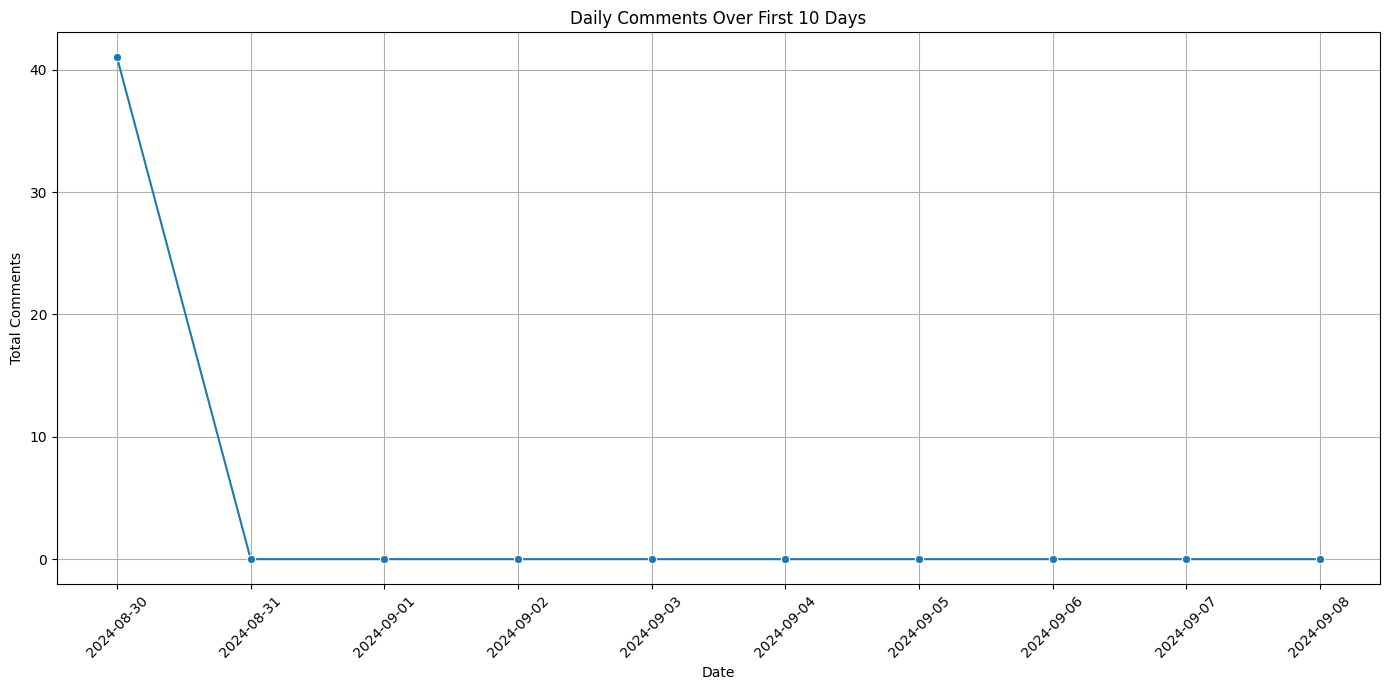

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'timestamp' to datetime objects
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

# Aggregate comments by date
daily_comments = df1.set_index('timestamp').resample('D')['comments'].sum().reset_index()

# Filter for the first 10 days
daily_comments_10_days = daily_comments.head(10)

# Create the plot
plt.figure(figsize=(14, 7))
sns.lineplot(x='timestamp', y='comments', data=daily_comments_10_days, marker='o')
plt.title('Daily Comments Over First 10 Days')
plt.xlabel('Date')
plt.ylabel('Total Comments')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hurdle Model for Instagram Comments

A hurdle model is a two-part model for count data with an excess of zeros. It consists of:

1.  **A binary model (e.g., Logistic Regression):** This models the probability of crossing the "hurdle" (i.e., having a non-zero count of shares).
2.  **A zero-truncated count model (e.g., Truncated Negative Binomial):** This models the count given that the hurdle has been crossed (i.e., only for posts with at least one share). Since `statsmodels` does not directly provide a zero-truncated negative binomial, we will use a standard Negative Binomial model on the subset of data where `Comments > 0`.

We will use the same comprehensive set of predictors `['pf', 'sf', 'sf2', 'time', 'logwc', 'saturation', 'post_interval', 'revenue', 'page active']` that was used in the ZINB model.

In [ ]:
# Define dependent and independent variables for the hurdle model
Y = df1['comments']
X_var = ['time', 'log(wc)', 'pf', 'saturation', 'post interval', 'revenue', 'posts','sf', 'sf2']
X = df1[X_var]

# Combine and drop NaNs to ensure consistent data
data_for_hurdle_model = pd.concat([Y, X], axis=1)

# Convert all X_var columns to numeric, coercing errors to NaN
for col in X_var:
 data_for_hurdle_model[col] = pd.to_numeric(data_for_hurdle_model[col], errors='coerce')

data_for_hurdle_model = data_for_hurdle_model.dropna(subset=['comments'] + X_var)

# Convert comments to integer for count models
data_for_hurdle_model['comments'] = data_for_hurdle_model['comments'].astype(float).astype(int)

# --- Part 1: Hurdle Model (Binary: comments > 0) ---
print("\n--- Hurdle Model Part 1: Logistic Regression for comments > 0 ---\n")

# Create a binary dependent variable: 1 if comments > 0, 0 otherwise
data_for_hurdle_model['has_comments'] = (data_for_hurdle_model['comments'] > 0).astype(int)

Y_binary = data_for_hurdle_model['has_comments']
X_binary = data_for_hurdle_model[X_var]

# Scale the independent variables for the binary part
scaler_binary = StandardScaler()
X_scaled_binary = scaler_binary.fit_transform(X_binary)
X_scaled_binary = pd.DataFrame(X_scaled_binary, columns=X_var, index=X_binary.index)

# Add a constant (intercept)
X_scaled_binary = sm.add_constant(X_scaled_binary, prepend=False)

try:
    logit_model = sm.Logit(Y_binary, X_scaled_binary)
    logit_results = logit_model.fit(disp=False, maxiter=1000)
    print(logit_results.summary())
except Exception as e:
    print(f"An error occurred during Logistic Regression: {e}")


--- Hurdle Model Part 1: Logistic Regression for comments > 0 ---

                           Logit Regression Results                           
Dep. Variable:           has_comments   No. Observations:                  542
Model:                          Logit   Df Residuals:                      532
Method:                           MLE   Df Model:                            9
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                 0.06543
Time:                        12:28:23   Log-Likelihood:                -345.57
converged:                       True   LL-Null:                       -369.76
Covariance Type:            nonrobust   LLR p-value:                 2.165e-07
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time              0.0358      0.116      0.309      0.757      -0.191       0.263
log(wc)           0.4095      0.100      4.114      0.

In [ ]:
# --- Part 2: Count Model (Negative Binomial for comments > 0) ---
print("\n--- Hurdle Model Part 2: Negative Binomial Regression for comments (when Shares > 0) ---\n")

# Filter data to include only posts with shares > 0
df_positive_comments = data_for_hurdle_model[data_for_hurdle_model['comments'] > 0].copy()

Y_count = df_positive_comments['comments']
X_count = df_positive_comments[X_var]

# Scale the independent variables for the count part using a *new* scaler or the previous one fitted on the full dataset (depending on preference)
# For consistency, we will fit a new scaler on the positive shares data
scaler_count = StandardScaler()
X_scaled_count = scaler_count.fit_transform(X_count)
X_scaled_count = pd.DataFrame(X_scaled_count, columns=X_var, index=X_count.index)

# Add a constant (intercept)
X_scaled_count = sm.add_constant(X_scaled_count, prepend=False)

try:
    nb_model = sm.NegativeBinomial(Y_count, X_scaled_count)
    # Try to get initial parameters, and if not available, create a default
    try:
        start_params_nb = nb_model.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        start_params_nb = np.zeros(len(X_scaled_count.columns) + 1) # exog_params + alpha

    nb_results = nb_model.fit(disp=False, maxiter=1000, start_params=start_params_nb)
    print(nb_results.summary())
except Exception as e:
    print(f"An error occurred during Negative Binomial Regression: {e}")


--- Hurdle Model Part 2: Negative Binomial Regression for comments (when Shares > 0) ---

                     NegativeBinomial Regression Results                      
Dep. Variable:               comments   No. Observations:                  311
Model:               NegativeBinomial   Df Residuals:                      301
Method:                           MLE   Df Model:                            9
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                0.009291
Time:                        12:28:23   Log-Likelihood:                -1587.1
converged:                       True   LL-Null:                       -1602.0
Covariance Type:            nonrobust   LLR p-value:                 0.0004802
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time             -0.0623      0.044     -1.414      0.157      -0.149       0.024
log(wc)           0.0483      0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
#Robustness Check for Negative Binomial Model
original_nbreg_model = sm.NegativeBinomial(Y_count, X_scaled_count)
original_nbreg_result = original_nbreg_model.fit(disp=False)

print("\n--- Original Negative Binomial Regression Results ---")
print(original_nbreg_result.summary())

# --- Robustness Check ---
# Randomly sample 90% of the data for the robustness check
sampled_df_positive_comments = df_positive_comments.sample(frac=0.9, random_state=42)

y_positive_sampled = sampled_df_positive_comments['comments']
X_positive_sampled = X_scaled_count.loc[sampled_df_positive_comments.index] # Ensure X aligns with sampled y

# Fit the Negative Binomial Regression model on the sampled data
nbreg_model_sampled = sm.NegativeBinomial(y_positive_sampled, X_positive_sampled)
nbreg_result_sampled = nbreg_model_sampled.fit(disp=False, maxiter=1000)

print("\n--- Robustness Check (90% Sampled Data) Negative Binomial Regression Results ---")
print(nbreg_result_sampled.summary())

# Create DataFrames for comparison
original_coef_pval = pd.DataFrame({
    'Original_Coef': original_nbreg_result.params,
    'Original_P_Value': original_nbreg_result.pvalues
})

sampled_coef_pval = pd.DataFrame({
    'Sampled_Coef': nbreg_result_sampled.params,
    'Sampled_P_Value': nbreg_result_sampled.pvalues
})

# Merge for side-by-side comparison
comparison_df = pd.merge(
    original_coef_pval, sampled_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) ---")
display(comparison_df.round(4))


--- Original Negative Binomial Regression Results ---
                     NegativeBinomial Regression Results                      
Dep. Variable:               comments   No. Observations:                  311
Model:               NegativeBinomial   Df Residuals:                      301
Method:                           MLE   Df Model:                            9
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                0.009291
Time:                        12:28:23   Log-Likelihood:                -1587.1
converged:                       True   LL-Null:                       -1602.0
Covariance Type:            nonrobust   LLR p-value:                 0.0004802
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time             -0.0623      0.044     -1.413      0.158      -0.149       0.024
log(wc)           0.0483      0.042      1.152      0.249      -0.0

,Original_Coef,Original_P_Value,Sampled_Coef,Sampled_P_Value
alpha,0.3674,0.0000,0.3628,0.0000
const,4.3007,0.0000,4.2846,0.0000
log(wc),0.0483,0.2492,0.0262,0.5483
pf,-0.0732,0.0569,-0.0770,0.0631
post interval,0.0314,0.3951,0.0320,0.3841
posts,0.1018,0.0193,0.1240,0.0074
revenue,0.0192,0.5880,0.0200,0.5826
saturation,0.1256,0.0023,0.1335,0.0023
sf,-0.2158,0.0236,-0.2364,0.0154
sf2,0.1489,0.1223,0.1693,0.0844


In [ ]:
#Robustness Check (90% Sampled Data) Logistic Regression Results
original_logit_model = sm.Logit(Y_binary, X_scaled_binary)
original_logit_result = original_logit_model.fit_regularized(method='l1', alpha=0.1, disp=False)

print("\n--- Original Logistic Regression Results ---")
print(original_logit_result.summary())

# --- Robustness Check for Logistic Regression ---
# Randomly sample 90% of the data for the robustness check
sampled_df_logit = data_for_hurdle_model.sample(frac=0.9, random_state=42)

y_binary_sampled = sampled_df_logit['has_comments']
X_sampled = X_scaled_binary.loc[sampled_df_logit.index] # Ensure X aligns with sampled y_binary

# Fit the Logistic Regression model on the sampled data
logit_model_sampled = sm.Logit(y_binary_sampled, X_sampled)
logit_result_sampled = logit_model_sampled.fit_regularized(method='l1', alpha=0.1, disp=False)

print("\n--- Robustness Check (90% Sampled Data) Logistic Regression Results ---")
print(logit_result_sampled.summary())

# Create DataFrames for comparison
original_logit_coef_pval = pd.DataFrame({
    'Original_Coef': original_logit_result.params,
    'Original_P_Value': original_logit_result.pvalues
})

sampled_logit_coef_pval = pd.DataFrame({
    'Sampled_Coef': logit_result_sampled.params,
    'Sampled_P_Value': logit_result_sampled.pvalues
})

# Merge for side-by-side comparison
comparison_logit_df = pd.merge(
    original_logit_coef_pval, sampled_logit_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) for Logistic Regression ---")
display(comparison_logit_df.round(4))


--- Original Logistic Regression Results ---
                           Logit Regression Results                           
Dep. Variable:           has_comments   No. Observations:                  542
Model:                          Logit   Df Residuals:                      532
Method:                           MLE   Df Model:                            9
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                 0.06542
Time:                        12:28:23   Log-Likelihood:                -345.57
converged:                       True   LL-Null:                       -369.76
Covariance Type:            nonrobust   LLR p-value:                 2.167e-07
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time              0.0364      0.116      0.314      0.753      -0.191       0.263
log(wc)           0.4077      0.099      4.100      0.000       0.213       

,Original_Coef,Original_P_Value,Sampled_Coef,Sampled_P_Value
const,0.3163,0.0005,0.3000,0.0017
log(wc),0.4077,0.0000,0.3993,0.0001
pf,-0.0511,0.5973,-0.0371,0.7108
post interval,0.0654,0.5395,0.0454,0.6880
posts,0.3779,0.0003,0.4053,0.0003
revenue,-0.0447,0.6283,-0.0514,0.5984
saturation,-0.3313,0.0011,-0.3582,0.0008
sf,-0.0803,0.7480,-0.0427,0.8687
sf2,0.1117,0.6597,0.0804,0.7563
time,0.0364,0.7532,-0.0145,0.9055


In [ ]:
#Robustness Check for Negative Binomial Model with Clustered Robust Standard Errors
# --- Ensure X and y are set up for the full model
features = ['time','log(wc)','pf','saturation','post interval','revenue','posts','sf','sf2']

y = df1['comments']
X = df1[features]

X = sm.add_constant(X)

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
X = X.fillna(X.mean())

constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)

df_positive_likes = df1[df1['comments'] > 0]
y_positive = df_positive_likes['comments']
X_positive = X.loc[df_positive_likes.index]

# --- Original Negative Binomial Model with Clustered Robust Standard Errors ---
original_nbreg_model_cluster = sm.NegativeBinomial(y_positive, X_positive)
original_nbreg_result_cluster = original_nbreg_model_cluster.fit(
    disp=False, maxiter=1000,
    cov_type='cluster', cov_kwds={'groups': df_positive_likes['posts']}
)

print("\n--- Original Negative Binomial Regression Results (Clustered Robust SE) ---")
print(original_nbreg_result_cluster.summary())

# --- Robustness Check (90% Sampled Data) with Clustered Robust Standard Errors ---
sampled_df_positive_likes = df_positive_likes.sample(frac=0.9, random_state=42)

y_positive_sampled = sampled_df_positive_likes['comments'] # Corrected: should be 'shares', not 'likes'
X_positive_sampled = X_positive.loc[sampled_df_positive_likes.index] # Ensure X aligns with sampled y

# Fit the Negative Binomial Regression model on the sampled data with clustered robust SE
nbreg_model_sampled_cluster = sm.NegativeBinomial(y_positive_sampled, X_positive_sampled)
nbreg_result_sampled_cluster = nbreg_model_sampled_cluster.fit(
    disp=False, maxiter=1000,
    cov_type='cluster', cov_kwds={'groups': sampled_df_positive_likes['posts']}
)

print("\n--- Robustness Check (90% Sampled Data) Negative Binomial Regression Results (Clustered Robust SE) ---")
print(nbreg_result_sampled_cluster.summary())

# --- Create DataFrames for comparison ---
original_cluster_coef_pval = pd.DataFrame({
    'Original_Cluster_Coef': original_nbreg_result_cluster.params,
    'Original_Cluster_P_Value': original_nbreg_result_cluster.pvalues
})

sampled_cluster_coef_pval = pd.DataFrame({
    'Sampled_Cluster_Coef': nbreg_result_sampled_cluster.params,
    'Sampled_Cluster_P_Value': nbreg_result_sampled_cluster.pvalues
})

# Merge for side-by-side comparison
comparison_cluster_df = pd.merge(
    original_cluster_coef_pval, sampled_cluster_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled with Clustered Robust SE) ---")
display(comparison_cluster_df.round(4))


--- Original Negative Binomial Regression Results (Clustered Robust SE) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:               comments   No. Observations:                  311
Model:               NegativeBinomial   Df Residuals:                      301
Method:                           MLE   Df Model:                            9
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                -0.08078
Time:                        12:28:23   Log-Likelihood:                -1731.4
converged:                      False   LL-Null:                       -1602.0
Covariance Type:              cluster   LLR p-value:                     1.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.7784      0.321     11.774      0.000       3.149       4.407
time             -0.0006      0.000     -1.38

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endo

,Original_Cluster_Coef,Original_Cluster_P_Value,Sampled_Cluster_Coef,Sampled_Cluster_P_Value
alpha,1.8023,0.3086,1.7773,0.3163
const,3.7784,0.0000,3.8305,0.0000
log(wc),0.1004,0.0887,0.0696,0.2941
pf,-0.0514,0.0104,-0.0534,0.0053
post interval,0.0388,0.0117,0.0383,0.0138
posts,0.0000,0.0013,0.0000,0.0000
revenue,0.0042,0.8495,0.0035,0.8795
saturation,0.0024,0.1230,0.0025,0.0990
sf,-0.0753,0.0519,-0.0829,0.0566
sf2,0.0046,0.1502,0.0052,0.1202


In [ ]:
# Robustness Check for Zero-Inflated Negative Binomial Model

# Define the full set of X_variables for ZINB model, including pf, sf, sf2
X_var_for_zinb_full = ['time', 'log(wc)', 'pf','saturation', 'post interval', 'revenue', 'posts','sf', 'sf2' ]

# --- Data Preparation for ZINB Model (with all features) ---
# This section ensures that the data used for the ZINB robustness check is consistent
# with the comprehensive ZINB model that includes 'pf', 'sf', and 'sf2'.
# It replicates the data preparation from cell 'ch2MrTk_ORyY'.

Y_comments_zinb_full = df1['comments']
X_comments_zinb_full = df1[X_var_for_zinb_full]

data_for_comments_model_full_features = pd.concat([Y_comments_zinb_full, X_comments_zinb_full], axis=1)

for col in X_var_for_zinb_full:
    data_for_comments_model_full_features[col] = pd.to_numeric(data_for_comments_model_full_features[col], errors='coerce')

data_for_comments_model_full_features = data_for_comments_model_full_features.dropna(subset=['comments'] + X_var_for_zinb_full)
data_for_comments_model_full_features['comments'] = data_for_comments_model_full_features['comments'].astype(float).astype(int)

Y_clear_full_features = data_for_comments_model_full_features['comments']
X_clear_full_features_unscaled = data_for_comments_model_full_features[X_var_for_zinb_full]

scaler_full_features_zinb = StandardScaler()
X_scaled_full_features = scaler_full_features_zinb.fit_transform(X_clear_full_features_unscaled)
X_clear_full_features = pd.DataFrame(X_scaled_full_features, columns=X_var_for_zinb_full, index=X_clear_full_features_unscaled.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear_full_features = sm.add_constant(X_clear_full_features, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_comments_full_features = X_clear_full_features

# --- Original Zero-Inflated Negative Binomial Regression Model ---
# Using the variables freshly prepared above
Y_clear_zinb = Y_clear_full_features
X_clear_zinb = X_clear_full_features
infl_comments_zinb = infl_comments_full_features

try:
    original_zinb_model = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear_zinb, exog=X_clear_zinb, exog_infl=infl_comments_zinb)
    # Attempt to get default start_params or initialize with zeros
    try:
        start_params_original_zinb = original_zinb_model.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        start_params_original_zinb = np.zeros(len(X_clear_zinb.columns) * 2 + 1)
    original_zinb_result = original_zinb_model.fit(maxiter=1000, disp=False, start_params=start_params_original_zinb)
    print("\n--- Original Zero-Inflated Negative Binomial Regression Results ---")
    print(original_zinb_result.summary())
except Exception as e:
    print(f"An error occurred during original ZINB model fitting: {e}")

# --- Robustness Check for Zero-Inflated Negative Binomial Regression ---
# Randomly sample 90% of the data for the robustness check
sampled_df_zinb_check = data_for_comments_model_full_features.sample(frac=0.9, random_state=42)

y_zinb_sampled = sampled_df_zinb_check['comments']

# Prepare exogenous variables for the sampled data
# Use the same scaler (scaler_full_features_zinb) that was fitted on the full data
X_zinb_sampled_unscaled = sampled_df_zinb_check[X_var_for_zinb_full]

X_zinb_sampled_scaled = scaler_full_features_zinb.transform(X_zinb_sampled_unscaled)
X_zinb_sampled = pd.DataFrame(X_zinb_sampled_scaled, columns=X_var_for_zinb_full, index=X_zinb_sampled_unscaled.index)

# Add a constant (intercept) to the independent variables
X_zinb_sampled = sm.add_constant(X_zinb_sampled, prepend=False)

# Fit the Zero-Inflated Negative Binomial Regression model on the sampled data
try:
    zinb_model_sampled = sm.ZeroInflatedNegativeBinomialP(endog=y_zinb_sampled, exog=X_zinb_sampled, exog_infl=X_zinb_sampled)
    # Attempt to get initial parameters or initialize with zeros
    try:
        start_params_sampled_zinb = zinb_model_sampled.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        start_params_sampled_zinb = np.zeros(len(X_zinb_sampled.columns) * 2 + 1)
    zinb_result_sampled = zinb_model_sampled.fit(maxiter=1000, disp=False, start_params=start_params_sampled_zinb)
    print("\n--- Robustness Check (90% Sampled Data) Zero-Inflated Negative Binomial Regression Results ---")
    print(zinb_result_sampled.summary())
except Exception as e:
    print(f"An error occurred during sampled ZINB model fitting: {e}")


# Create DataFrames for comparison
original_zinb_coef_pval = pd.DataFrame({
    'Original_Coef': original_zinb_result.params,
    'Original_P_Value': original_zinb_result.pvalues
})

sampled_zinb_coef_pval = pd.DataFrame({
    'Sampled_Coef': zinb_result_sampled.params,
    'Sampled_P_Value': zinb_result_sampled.pvalues
})

# Merge for side-by-side comparison
comparison_zinb_df = pd.merge(
    original_zinb_coef_pval, sampled_zinb_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) for Zero-Inflated Negative Binomial Regression ---")
display(comparison_zinb_df.round(4))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:4329: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/usr/local/lib/python3.12/dist-packages/statsmodel


--- Original Zero-Inflated Negative Binomial Regression Results ---
                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                          comments   No. Observations:                  542
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      532
Method:                                      MLE   Df Model:                            9
Date:                           Thu, 23 Jul 2026   Pseudo R-squ.:                     nan
Time:                                   12:28:24   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                       -1971.7
Covariance Type:                       nonrobust   LLR p-value:                       nan
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time            -29.755

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:4329: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/usr/local/lib/python3.12/dist-packages/statsmodel


--- Robustness Check (90% Sampled Data) Zero-Inflated Negative Binomial Regression Results ---
                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                          comments   No. Observations:                  488
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      478
Method:                                      MLE   Df Model:                            9
Date:                           Thu, 23 Jul 2026   Pseudo R-squ.:                     nan
Time:                                   12:28:25   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                       -1764.3
Covariance Type:                       nonrobust   LLR p-value:                       nan
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
infl

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


,Original_Coef,Original_P_Value,Sampled_Coef,Sampled_P_Value
alpha,-1436.1168,NaN,-1427.0645,NaN
const,6776.6727,NaN,6699.1706,NaN
inflate_const,-132.3118,NaN,-127.5213,NaN
inflate_log(wc),-27.2571,NaN,-24.7097,NaN
inflate_pf,12.6329,NaN,12.1416,NaN
inflate_post interval,-15.6587,NaN,-7.5676,NaN
inflate_posts,-42.7259,NaN,-40.9911,NaN
inflate_revenue,7.3441,NaN,4.2647,NaN
inflate_saturation,35.3712,NaN,35.1586,NaN
inflate_sf,-4.0697,NaN,-5.7290,NaN


/tmp/ipykernel_2553/1461654555.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_name', y='engagement_intensity', data=avg_engagement_per_day, palette='viridis')


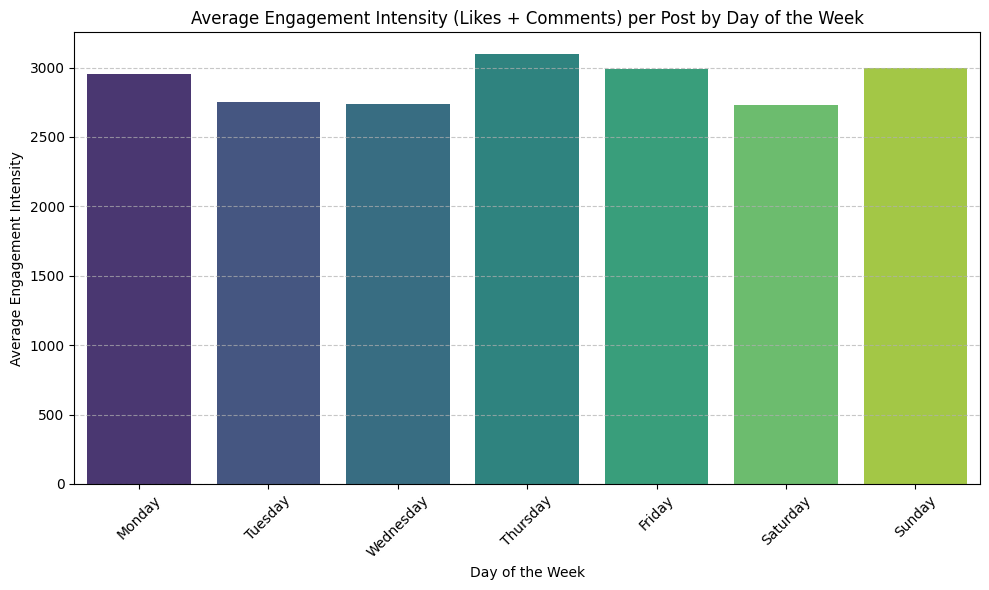

In [ ]:
# Calculate engagement intensity (likes + comments)
df1['engagement_intensity'] = df1['likes'] + df1['comments']

# Ensure 'timestamp' is in datetime format (if not already)
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

# Extract the day of the week (Monday=0, Sunday=6)
df1['day_of_week'] = df1['timestamp'].dt.dayofweek

# Group by day of the week and calculate the mean of 'engagement_intensity'
avg_engagement_per_day = df1.groupby('day_of_week')['engagement_intensity'].mean().reset_index()

# Map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_engagement_per_day['day_name'] = avg_engagement_per_day['day_of_week'].map(lambda x: day_names[x])

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='engagement_intensity', data=avg_engagement_per_day, palette='viridis')
plt.title('Average Engagement Intensity (Likes + Comments) per Post by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Engagement Intensity')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()